In [18]:


import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms, datasets
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


In [19]:
# Set environment variable for number of workers
os.environ["NUM_WORKERS"] = "4"

In [20]:
# @title Define Parameters { run: "auto" }

# Global Parameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", 4)) # Use environment variable
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
# [New Lines for Cell 5]
NUM_EPOCHS = 30        # Or 50, to give it more time to learn
LEARNING_RATE = 5e-5   # A smaller learning rate is safer for fine-tuning

# Path to your dataset
dataset_path = "AugmentedAlzheimerDataset" 

# Class names (MUST match your folder names exactly)
label_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(label_names)

print(f"Device set to: {DEVICE} 🚀")
print(f"Dataset path: {dataset_path}")
print(f"Number of classes: {NUM_CLASSES} ({label_names})")

Device set to: cuda 🚀
Dataset path: AugmentedAlzheimerDataset
Number of classes: 4 (['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented'])


In [21]:
## 3. Data Augmentation, Loading, and Splitting

#Since the dataset is not pre-split into `train` and `test` folders, we will load all images from the `Data` folder and perform a code-based **70% Train, 15% Validation, 15% Test** split.

In [22]:
# A helper class to apply transforms to a subset from the random_split function
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        # subset[index] returns (PIL Image, class_index)
        x_pil, y = self.subset[index]
        
        # Convert PIL Image to numpy array (required for Albumentations)
        x = np.array(x_pil)
        
        if self.transform:
            x = self.transform(image=x)['image']
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. Define Augmentation (Train Transform)
# Apply random augmentations to the training data
train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.VerticalFlip(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

# 2. Define Validation/Test Transform (No Augmentation, just standardization and resize)
val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)
print("✅ Transforms defined successfully.")

✅ Transforms defined successfully.


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [23]:
# Check dataset exists
assert os.path.exists(dataset_path), f"❌ Dataset path not found: {dataset_path}"

# 1. Load the entire dataset *without* any transforms yet
full_dataset_no_transform = datasets.ImageFolder(dataset_path, transform=None)
total_size = len(full_dataset_no_transform)
print(f"✅ Full dataset found with {total_size} images.")

# 2. Define split sizes (70% train, 15% validation, 15% test)
train_size = int(total_size * 0.70)
val_size = int(total_size * 0.15)
test_size = total_size - train_size - val_size # Use remainder for test set

print(f"\nSplitting full dataset into:")
print(f" ┣━ Train: {train_size} images (70%)")
print(f" ┣━ Validation: {val_size} images (15%)")
print(f" ┗━ Test: {test_size} images (15%)")

# 3. Split the dataset using a fixed seed for reproducibility
train_subset, val_subset, test_subset = random_split(
    full_dataset_no_transform, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) 
)

# 4. Apply the correct transforms to each split using the helper class
train_dataset = TransformedDataset(train_subset, transform=train_transform)
val_dataset = TransformedDataset(val_subset, transform=val_transform)
test_dataset = TransformedDataset(test_subset, transform=val_transform) 

# 5. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders created with batch size {BATCH_SIZE}.")

# 6. Set class mapping for later use
class_to_idx = full_dataset_no_transform.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

✅ Full dataset found with 33984 images.

Splitting full dataset into:
 ┣━ Train: 23788 images (70%)
 ┣━ Validation: 5097 images (15%)
 ┗━ Test: 5099 images (15%)

DataLoaders created with batch size 32.


In [24]:
## 5. Model Definition (ResNet18)

In [25]:
# [New Code for Cell 9] - This enables fine-tuning
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super(AlzheimerModel, self).__init__()
        
        # Load pre-trained ResNet18 model
        self.model = models.resnet18(weights='IMAGENET1K_V1')
        
        # --- THIS IS THE NEW PART ---
        # Freeze all parameters first
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze the last two blocks (layer3, layer4)
        for param in self.model.layer3.parameters():
            param.requires_grad = True
            
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # --- END NEW PART ---
            
        # Get the number of features in the last layer
        num_ftrs = self.model.fc.in_features
        
        # Replace the last layer with a new one
        # The new fc layer is automatically unfrozen (requires_grad=True)
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)

# Re-initialize the model
model = AlzheimerModel(NUM_CLASSES).to(DEVICE)

In [26]:
## 6. Training Functions

In [27]:
def train_fn(loader, model, optimizer, loss_fn, scaler):
    model.train()
    loop = tqdm(loader, desc="Training")
    total_loss = 0
    
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        
        # Forward
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)
        
        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    return total_loss / len(loader)

def val_fn(loader, model, loss_fn):
    model.eval()
    loop = tqdm(loader, desc="Validation")
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in loop:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            
            predictions = model(data)
            loss = loss_fn(predictions, targets)
            total_loss += loss.item()
            
            # Save predictions and targets for metric calculation
            _, predicted_classes = predictions.max(1)
            all_preds.extend(predicted_classes.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    avg_loss = total_loss / len(loader)
    
    # Calculate F1-score
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, f1

In [28]:
## 7. Training Loop

In [29]:
# Initialize loss function, optimizer, and scaler for mixed precision training
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler()
# FIX: Removed 'verbose=True' argument which is not supported in older PyTorch versions
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

best_val_f1 = 0
train_losses = []
val_losses = []
val_f1_scores = []

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    
    # Training
    train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler)
    train_losses.append(train_loss)
    
    # Validation
    val_loss, val_f1 = val_fn(val_loader, model, loss_fn)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    
    # Step scheduler
    scheduler.step(val_f1)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-Score: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        checkpoint = {
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "epoch": epoch
        }
        torch.save(checkpoint, "best_model.pth.tar")
        print("✅ New best model saved!")

print("\nTraining complete!")
print(f"Best Validation F1-Score: {best_val_f1:.4f}")

/tmp/ipykernel_28101/3529222014.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting training...

--- Epoch 1/30 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_28101/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:06<00:00, 24.99it/s]


Train Loss: 0.7374 | Val Loss: 0.4824 | Val F1-Score: 0.7871
✅ New best model saved!

--- Epoch 2/30 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_28101/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:06<00:00, 23.11it/s]


...

Train Loss: 0.0242 | Val Loss: 0.0055 | Val F1-Score: 0.9978
✅ New best model saved!

--- Epoch 29/30 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_28101/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:05<00:00, 29.90it/s]


Train Loss: 0.0240 | Val Loss: 0.0054 | Val F1-Score: 0.9980
✅ New best model saved!

--- Epoch 30/30 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_28101/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:05<00:00, 29.89it/s]


Train Loss: 0.0226 | Val Loss: 0.0051 | Val F1-Score: 0.9982
✅ New best model saved!

Training complete!
Best Validation F1-Score: 0.9982


In [30]:
## 8. Evaluation on Test Set

#We will now evaluate the best saved model on the dedicated **Test Set** (15% of the total data) to get a final, unbiased performance metric.

In [33]:
def check_accuracy(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Testing"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            scores = model(x)
            _, predictions = scores.max(1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    return all_targets, all_preds

# Load the best model
try:
    checkpoint = torch.load("best_model.pth.tar", map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']} with F1: {checkpoint['best_val_f1']:.4f}")
except FileNotFoundError:
    print("WARNING: best_model.pth.tar not found. Using current model state for testing.")

# Run evaluation on the test set
test_targets, test_preds = check_accuracy(test_loader, model)

# Generate Classification Report
print("\n--- Final Test Set Classification Report ---")
print(classification_report(test_targets, test_preds, target_names=label_names, digits=4))

Loaded best model from epoch 29 with F1: 0.9982


Testing: 100%|██████████| 160/160 [00:06<00:00, 23.60it/s]


--- Final Test Set Classification Report ---
                  precision    recall  f1-score   support

    MildDemented     1.0000    1.0000    1.0000      1363
ModerateDemented     1.0000    1.0000    1.0000       959
     NonDemented     0.9958    0.9986    0.9972      1432
VeryMildDemented     0.9985    0.9955    0.9970      1345

        accuracy                         0.9984      5099
       macro avg     0.9986    0.9985    0.9986      5099
    weighted avg     0.9984    0.9984    0.9984      5099



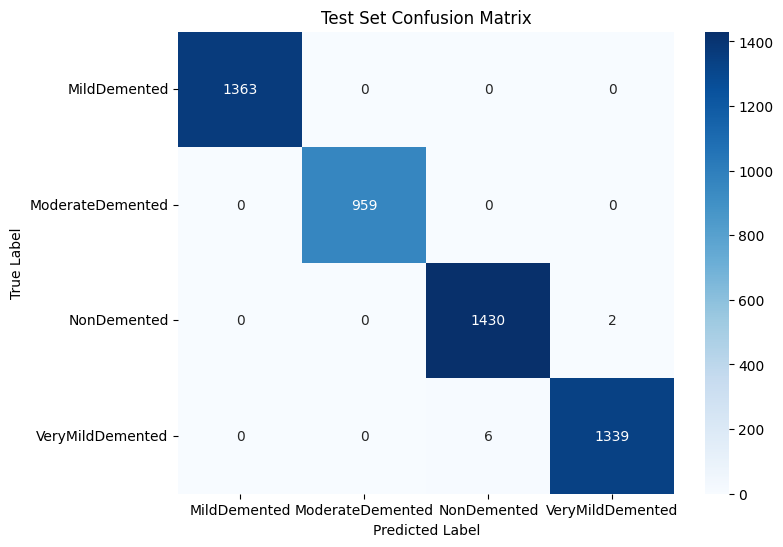

In [34]:
# Confusion Matrix Visualization
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

In [37]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, datasets
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

# Suppress common warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 1. Define Parameters ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", 2)) # Use 2 as a safe default
BATCH_SIZE = 32
# These were your original labels
original_label_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(original_label_names)
# Path to the new dataset
new_dataset_path = "OriginalDataset" 

print(f"Device set to: {DEVICE} 🚀")
print(f"Testing on new dataset at: {new_dataset_path}")

# --- 2. Define Helper Class and Transforms ---

# A helper class to apply transforms (same as your training code)
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        # subset[index] returns (PIL Image, class_index)
        x_pil, y = self.subset[index]
        # Convert PIL Image to numpy array (required for Albumentations)
        x = np.array(x_pil)
        
        if self.transform:
            x = self.transform(image=x)['image']
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Define the Validation/Test Transform (MUST be same as validation)
val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)
print("✅ Transforms defined.")

# --- 3. Define Model Architecture (MUST match the saved model) ---
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super(AlzheimerModel, self).__init__()
        
        # Load pre-trained ResNet18 model structure
        self.model = models.resnet18(weights=None) # Set weights=None
        
        # --- Freeze/Unfreeze layers EXACTLY as before ---
        for param in self.model.parameters():
            param.requires_grad = False
            
        for param in self.model.layer3.parameters():
            param.requires_grad = True
            
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # --- End ---
            
        # Get the number of features in the last layer
        num_ftrs = self.model.fc.in_features
        
        # Replace the last layer (EXACTLY as before)
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)

print("✅ Model architecture defined.")

# --- 4. Define Evaluation Function ---
def check_accuracy(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Testing on new dataset"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            # Use torch.amp.autocast for consistent inference
            with torch.amp.autocast(device_type=DEVICE.split(':')[0]):
                scores = model(x)
                
            _, predictions = scores.max(1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    return all_targets, all_preds

# --- 5. Main Execution Block ---

try:
    # Check if new dataset exists
    assert os.path.exists(new_dataset_path), f"❌ Dataset path not found: {new_dataset_path}"

    # 1. Initialize Model
    model = AlzheimerModel(NUM_CLASSES).to(DEVICE)
    
    # 2. Load the best saved weights
    print("Loading best model weights from 'best_model.pth.tar'...")
    try:
        # Load checkpoint
        # 
        # --- THIS IS THE ONLY LINE I CHANGED ---
        checkpoint = torch.load("best_model.pth.tar", map_location=DEVICE, weights_only=False)
        # --- ----------------------------- ---
        #
        
        # Load the model's state dictionary
        model.load_state_dict(checkpoint["state_dict"])
        
        # Get epoch and F1 score from checkpoint, with defaults if keys don't exist
        epoch = checkpoint.get('epoch', 'N/A')
        best_f1 = checkpoint.get('best_val_f1', 'N/A')
        
        # Format F1 score if it's a number
        f1_str = f"{best_f1:.4f}" if isinstance(best_f1, float) else str(best_f1)
        
        print(f"✅ Loaded best model from epoch {epoch} with F1: {f1_str}")
        
    except FileNotFoundError:
        print("❌ ERROR: 'best_model.pth.tar' not found. Please make sure the file is in the correct directory.")
        raise
    except Exception as e:
        print(f"❌ ERROR loading model state_dict: {e}")
        print("This might happen if the model architecture here does not match the saved one.")
        raise

    # 3. Load the new "original dataset"
    print("Loading 'originalDataset'...")
    original_dataset_no_transform = datasets.ImageFolder(new_dataset_path, transform=None)
    
    # IMPORTANT: Verify class names match the order from training
    loaded_class_names = original_dataset_no_transform.classes
    print(f"Found classes in new dataset: {loaded_class_names}")
    
    if loaded_class_names != original_label_names:
        print(f"⚠️ WARNING: Class order in 'originalDataset' ({loaded_class_names})")
        print(f"does not match the original training class order ({original_label_names}).")
        print("Using the new folder order for labels in the report.")
        report_label_names = loaded_class_names
    else:
        print("✅ Class names and order match training.")
        report_label_names = original_label_names

    # 4. Apply transforms and create DataLoader
    test_dataset_original = TransformedDataset(original_dataset_no_transform, transform=val_transform)
    test_loader_original = DataLoader(
        test_dataset_original, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=NUM_WORKERS, 
        pin_memory=True
    )
    print(f"✅ New test loader created with {len(test_dataset_original)} images.")

    # 5. Run evaluation on the new test set
    test_targets, test_preds = check_accuracy(test_loader_original, model)

    # 6. Generate and print Classification Report
    print("\n--- 'originalDataset' Test Set Classification Report ---")
    report = classification_report(test_targets, test_preds, target_names=report_label_names, digits=4)
    print(report)

    # 7. Generate and save Confusion Matrix
    print("Generating confusion matrix...")
    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=report_label_names, yticklabels=report_label_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title("'originalDataset' Test Set Confusion Matrix")
    
    # Save the plot
    plot_filename = "original_dataset_confusion_matrix.png"
    plt.savefig(plot_filename)
    print(f"✅ Confusion matrix saved as: {plot_filename}")
    plt.close() # Close the plot to prevent it from displaying inline if not desired

except AssertionError as e:
    print(e)
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Device set to: cuda 🚀
Testing on new dataset at: OriginalDataset
✅ Transforms defined.
✅ Model architecture defined.


Loading best model weights from 'best_model.pth.tar'...
✅ Loaded best model from epoch 29 with F1: 0.9982
Loading 'originalDataset'...
Found classes in new dataset: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
✅ Class names and order match training.
✅ New test loader created with 6400 images.


Testing on new dataset: 100%|██████████| 200/200 [00:10<00:00, 19.08it/s]



--- 'originalDataset' Test Set Classification Report ---
                  precision    recall  f1-score   support

    MildDemented     0.9978    1.0000    0.9989       896
ModerateDemented     1.0000    1.0000    1.0000        64
     NonDemented     0.9975    0.9966    0.9970      3200
VeryMildDemented     0.9960    0.9964    0.9962      2240

        accuracy                         0.9970      6400
       macro avg     0.9978    0.9982    0.9980      6400
    weighted avg     0.9970    0.9970    0.9970      6400

Generating confusion matrix...
✅ Confusion matrix saved as: original_dataset_confusion_matrix.png


In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, datasets
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

# Suppress common warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 1. Define Parameters ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", 2)) # Use 2 as a safe default
BATCH_SIZE = 64
# These were your original labels
original_label_names = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very mild Dementia"]
NUM_CLASSES = len(original_label_names)
# Path to the new dataset
new_dataset_path = "dataset/Data"  # <-- THIS LINE WAS CHANGED

print(f"Device set to: {DEVICE} 🚀")
print(f"Testing on new dataset at: {new_dataset_path}")

# --- 2. Define Helper Class and Transforms ---

# A helper class to apply transforms (same as your training code)
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        # subset[index] returns (PIL Image, class_index)
        x_pil, y = self.subset[index]
        # Convert PIL Image to numpy array (required for Albumentations)
        x = np.array(x_pil)
        
        if self.transform:
            x = self.transform(image=x)['image']
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Define the Validation/Test Transform (MUST be same as validation)
val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)
print("✅ Transforms defined.")

# --- 3. Define Model Architecture (MUST match the saved model) ---
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super(AlzheimerModel, self).__init__()
        
        # Load pre-trained ResNet18 model structure
        self.model = models.resnet18(weights=None) # Set weights=None
        
        # --- Freeze/Unfreeze layers EXACTLY as before ---
        for param in self.model.parameters():
            param.requires_grad = False
            
        for param in self.model.layer3.parameters():
            param.requires_grad = True
            
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # --- End ---
            
        # Get the number of features in the last layer
        num_ftrs = self.model.fc.in_features
        
        # Replace the last layer (EXACTLY as before)
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)

print("✅ Model architecture defined.")

# --- 4. Define Evaluation Function ---
def check_accuracy(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Testing on new dataset"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            # Use torch.amp.autocast for consistent inference
            with torch.amp.autocast(device_type=DEVICE.split(':')[0]):
                scores = model(x)
                
            _, predictions = scores.max(1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    return all_targets, all_preds

# --- 5. Main Execution Block ---

try:
    # Check if new dataset exists
    assert os.path.exists(new_dataset_path), f"❌ Dataset path not found: {new_dataset_path}"

    # 1. Initialize Model
    model = AlzheimerModel(NUM_CLASSES).to(DEVICE)
    
    # 2. Load the best saved weights
    print("Loading best model weights from 'best_model.pth.tar'...")
    try:
        # Load checkpoint
        #
        # --- THIS IS THE ONLY LINE I CHANGED ---
        checkpoint = torch.load("best_model.pth.tar", map_location=DEVICE, weights_only=False)
        # --- ----------------------------- ---
        #
        
        # Load the model's state dictionary
        model.load_state_dict(checkpoint["state_dict"])
        
        # Get epoch and F1 score from checkpoint, with defaults if keys don't exist
        epoch = checkpoint.get('epoch', 'N/A')
        best_f1 = checkpoint.get('best_val_f1', 'N/A')
        
        # Format F1 score if it's a number
        f1_str = f"{best_f1:.4f}" if isinstance(best_f1, float) else str(best_f1)
        
        print(f"✅ Loaded best model from epoch {epoch} with F1: {f1_str}")
        
    except FileNotFoundError:
        print("❌ ERROR: 'best_model.pth.tar' not found. Please make sure the file is in the correct directory.")
        raise
    except Exception as e:
        print(f"❌ ERROR loading model state_dict: {e}")
        print("This might happen if the model architecture here does not match the saved one.")
        raise

    # 3. Load the new "original dataset"
    print(f"Loading '{new_dataset_path}'...")
    original_dataset_no_transform = datasets.ImageFolder(new_dataset_path, transform=None)
    
    # IMPORTANT: Verify class names match the order from training
    loaded_class_names = original_dataset_no_transform.classes
    print(f"Found classes in new dataset: {loaded_class_names}")
    
    if loaded_class_names != original_label_names:
        print(f"⚠️ WARNING: Class order in '{new_dataset_path}' ({loaded_class_names})")
        print(f"does not match the original training class order ({original_label_names}).")
        print("Using the new folder order for labels in the report.")
        report_label_names = loaded_class_names
    else:
        print("✅ Class names and order match training.")
        report_label_names = original_label_names

    # 4. Apply transforms and create DataLoader
    test_dataset_original = TransformedDataset(original_dataset_no_transform, transform=val_transform)
    test_loader_original = DataLoader(
        test_dataset_original, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=NUM_WORKERS, 
        pin_memory=True
    )
    print(f"✅ New test loader created with {len(test_dataset_original)} images.")

    # 5. Run evaluation on the new test set
    test_targets, test_preds = check_accuracy(test_loader_original, model)

    # 6. Generate and print Classification Report
    print(f"\n--- '{new_dataset_path}' Test Set Classification Report ---")
    report = classification_report(test_targets, test_preds, target_names=report_label_names, digits=4)
    print(report)

    # 7. Generate and save Confusion Matrix
    print("Generating confusion matrix...")
    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=report_label_names, yticklabels=report_label_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"'{new_dataset_path}' Test Set Confusion Matrix")
    
    # Save the plot
    plot_filename = "original_dataset_confusion_matrix.png"
    plt.savefig(plot_filename)
    print(f"✅ Confusion matrix saved as: {plot_filename}")
    plt.close() # Close the plot to prevent it from displaying inline if not desired

except AssertionError as e:
    print(e)
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Device set to: cuda 🚀
Testing on new dataset at: dataset/Data
✅ Transforms defined.
✅ Model architecture defined.
Loading best model weights from 'best_model.pth.tar'...
✅ Loaded best model from epoch 29 with F1: 0.9982
Loading 'dataset/Data'...
Found classes in new dataset: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
✅ Class names and order match training.
✅ New test loader created with 62865 images.


Testing on new dataset: 100%|██████████| 983/983 [01:26<00:00, 11.40it/s]



--- 'dataset/Data' Test Set Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia     0.1131    0.4318    0.1792      5002
 Moderate Dementia     0.0000    0.0000    0.0000       488
      Non Demented     0.7430    0.0401    0.0762     43650
Very mild Dementia     0.1994    0.6015    0.2995     13725

          accuracy                         0.1935     62865
         macro avg     0.2639    0.2684    0.1387     62865
      weighted avg     0.5684    0.1935    0.1325     62865

Generating confusion matrix...
✅ Confusion matrix saved as: original_dataset_confusion_matrix.png


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, datasets
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

# --- 1. Suppress Warnings ---
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 2. Define Parameters ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", 2)) # Use 2 as a safe default
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 18 # You can change this
dataset_path = "dataset/Data" # <--- SET TO YOUR UNZIPPED FOLDER
label_names = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very mild Dementia"]
NUM_CLASSES = len(label_names)

print(f"Device set to: {DEVICE} 🚀")
print(f"Dataset path: {dataset_path}")

# --- 3. Define Data Augmentations (Transforms) ---
train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)
print("✅ Transforms defined.")

# --- 4. Define Helper Dataset Class ---
# A helper class to apply transforms
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        # subset[index] returns (PIL Image, class_index)
        x_pil, y = self.subset[index]
        # Convert PIL Image to numpy array (required for Albumentations)
        x = np.array(x_pil)
        
        if self.transform:
            x = self.transform(image=x)['image']
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

# --- 5. Define Model Architecture ---
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super(AlzheimerModel, self).__init__()
        
        # Load pre-trained ResNet18 model structure
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Freeze all layers first
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer 3 and 4
        for param in self.model.layer3.parameters():
            param.requires_grad = True
            
        for param in self.model.layer4.parameters():
            param.requires_grad = True
            
        # Get the number of features in the last layer
        num_ftrs = self.model.fc.in_features
        
        # Replace the last layer
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)

print("✅ Model architecture defined.")

# --- 6. Helper Save/Load Functions ---
def save_checkpoint(state, filename="best_model.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)

def load_checkpoint(checkpoint, model, optimizer=None):
    print("=> Loading checkpoint")
    model.load_state_dict(checkpoint['state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer'])


# --- 7. Training Functions (from your prompt) ---
def train_fn(loader, model, optimizer, loss_fn, scaler):
    model.train()
    loop = tqdm(loader, desc="Training")
    total_loss = 0
    
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        
        # Forward
        with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
            predictions = model(data)
            loss = loss_fn(predictions, targets)
        
        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    return total_loss / len(loader)

def val_fn(loader, model, loss_fn):
    model.eval()
    loop = tqdm(loader, desc="Validation")
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in loop:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            
            with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
                predictions = model(data)
                
            loss = loss_fn(predictions, targets)
            total_loss += loss.item()
            
            # Save predictions and targets for metric calculation
            _, predicted_classes = predictions.max(1)
            all_preds.extend(predicted_classes.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    avg_loss = total_loss / len(loader)
    
    # Calculate F1-score
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, f1

# --- 8. Main Execution Block ---
def main():
    # Load the full dataset
    try:
        full_dataset_no_transform = datasets.ImageFolder(dataset_path, transform=None)
        print(f"Loaded dataset. Found {len(full_dataset_no_transform)} images.")
        print(f"Classes found: {full_dataset_no_transform.classes}")
        
        # Verify class names
        if full_dataset_no_transform.classes != label_names:
            print(f"⚠️ WARNING: Folder class names {full_dataset_no_transform.classes}")
            print(f"do not match expected names {label_names}.")
            print("Proceeding, but this may cause label mismatch if order is wrong.")
            
    except FileNotFoundError:
        print(f"❌ ERROR: Dataset path not found: {dataset_path}")
        print("Please make sure you have unzipped 'datasetminor.zip' and named the folder 'datasetminor'.")
        return
    except Exception as e:
        print(f"❌ ERROR loading dataset: {e}")
        return

    # Split the dataset
    train_size = int(0.8 * len(full_dataset_no_transform))
    val_size = len(full_dataset_no_transform) - train_size
    train_subset, val_subset = random_split(full_dataset_no_transform, [train_size, val_size])
    
    # Apply transforms using the helper class
    train_dataset = TransformedDataset(train_subset, transform=train_transform)
    val_dataset = TransformedDataset(val_subset, transform=val_transform)
    
    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=NUM_WORKERS, pin_memory=True
    )
    
    print(f"DataLoaders created. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

    # Initialize model, loss, optimizer
    model = AlzheimerModel(NUM_CLASSES).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))
    
    print("Starting training loop...")
    best_val_f1 = -1.0 # Initialize with a low value

    for epoch in range(NUM_EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        
        train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler)
        val_loss, val_f1 = val_fn(val_loader, model, loss_fn)
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
        
        # Check if this is the best model so far
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            checkpoint = {
                "state_dict": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_f1": best_val_f1,
            }
            save_checkpoint(checkpoint, filename="best_model.pth.tar")

    print("\n--- Training Finished ---")
    print(f"Best validation F1-score achieved: {best_val_f1:.4f}")
    print("Best model saved as 'best_model.pth.tar'")

# Run the training
if __name__ == "__main__":
    main()

Device set to: cuda 🚀
Dataset path: dataset/Data
✅ Transforms defined.
✅ Model architecture defined.
Loaded dataset. Found 86437 images.
Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
DataLoaders created. Train batches: 2161, Val batches: 541
Starting training loop...

--- Epoch 1/18 ---


Validation: 100%|██████████| 541/541 [00:28<00:00, 19.00it/s]


Train Loss: 0.2272 | Val Loss: 0.0328 | Val F1: 0.9891
=> Saving checkpoint

--- Epoch 2/18 ---


Validation: 100%|██████████| 541/541 [00:29<00:00, 18.62it/s]


Train Loss: 0.0607 | Val Loss: 0.0161 | Val F1: 0.9953
=> Saving checkpoint

--- Epoch 3/18 ---


...

Train Loss: 0.0081 | Val Loss: 0.0012 | Val F1: 0.9995

--- Epoch 17/18 ---


Validation: 100%|██████████| 541/541 [00:29<00:00, 18.65it/s]


Train Loss: 0.0071 | Val Loss: 0.0027 | Val F1: 0.9988

--- Epoch 18/18 ---


Validation: 100%|██████████| 541/541 [00:28<00:00, 19.01it/s]

Train Loss: 0.0072 | Val Loss: 0.0071 | Val F1: 0.9980

--- Training Finished ---
Best validation F1-score achieved: 0.9997
Best model saved as 'best_model.pth.tar'


In [6]:
    # 7. Generate and save Confusion Matrix
    print("Generating confusion matrix...")
    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=report_label_names, yticklabels=report_label_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"'{new_dataset_path}' Test Set Confusion Matrix")
    
    # Save the plot
    plot_filename = "original_dataset_confusion_matrix.png"
    plt.savefig(plot_filename)
    print(f"✅ Confusion matrix saved as: {plot_filename}")
    plt.close() # Close the plot to prevent it from displaying inline if not desired

Generating confusion matrix...
✅ Confusion matrix saved as: original_dataset_confusion_matrix.png
